# World Cup Predictor: Episode 2 - Logistic Regression Model
By Karl Estampador :)

## What this notebook does

Episode 1 used a purely deterministic ELO model. Episode 2 replaces that with a **Logistic Regression model** trained on historical World Cup matches (2002-2022). Instead of a single ELO number per team, the model learns from seven pre-tournament team features - things like FIFA rank difference, squad market value ratio, and goal-scoring form - to estimate the probability of a home win, draw, or away win.

## How to use in `predictions.ipynb`

Swap out the ELO model by replacing the first `%run` call:

```python
# Before (Episode 1):
%run model.ipynb

# After (Episode 2):
%run lr_model.ipynb
```

The functions `predict_winner`, `predict_score`, and `get_elo` are all exposed so `predictions.ipynb` works without changes. Match outcomes use LR; `get_elo` is only used for the standings table and tiebreakers.

## Training data note

We train on ~378 World Cup group and knockout matches from 2002-2022 (6 tournaments x 64 matches, minus a handful dropped due to team-name mismatches between data sources). This is a **small dataset** by ML standards. Vanilla LR with standardization is the right tool here - no over-engineering.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import log_loss, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
DATA = Path('data')
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok=True)

print('Imports OK')

Imports OK


---
## Step 1 - Data Cleaning & Join

There are three data sources involved:

| File | What it contains |
|---|---|
| `data/historical_results/results.csv` | Every international match result since 1872 (same schema as the Kaggle dataset) |
| `data/historical_results/shootouts.csv` | Penalty shootout winners - needed to resolve knockout-round draws |
| `data/train.csv` | Pre-tournament team stats for every WC participant 2002-2022 |

In [ ]:
# Load raw data 

results_all = pd.read_csv(DATA / 'historical_results' / 'results.csv')
shootouts_all = pd.read_csv(DATA / 'historical_results' / 'shootouts.csv')
train_df = pd.read_csv(DATA / 'train.csv')
test_df  = pd.read_csv(DATA / 'test.csv')

# Filter results to World Cup matches only, years 2002 - 2022
results_all['year'] = pd.to_datetime(results_all['date']).dt.year
wc_mask = (
    (results_all['tournament'] == 'FIFA World Cup') &
    (results_all['year'].between(2002, 2022))
)
wc = results_all[wc_mask].copy().reset_index(drop=True)

# Also filter shootouts to the same WC years
shootouts_all['year'] = pd.to_datetime(shootouts_all['date']).dt.year
wc_shootouts = shootouts_all[
    (shootouts_all['year'].between(2002, 2022))
].copy()

print(f'WC matches 2002 - 2022: {len(wc)}')
print('Matches per tournament:')
print(wc['year'].value_counts().sort_index())
print(f'\nShootout records in same period: {len(wc_shootouts)}')
print(f'\ntrain.csv rows: {len(train_df)} | test.csv rows: {len(test_df)}')

WC matches 2002 - 2022: 384
Matches per tournament:
year
2002    64
2006    64
2010    64
2014    64
2018    64
2022    64
Name: count, dtype: int64

Shootout records in same period: 310

train.csv rows: 192 | test.csv rows: 48


### 1b) Team name normalisation

The `results.csv` and `train.csv` files use slightly different names for some teams. We need to normalise the results names **before** joining. After auditing both files, only two mismatches affect the 2002 - 2022 period:

| results.csv | train.csv | Years |
|---|---|---|
| `"China"` | `"China PR"` | 2002 |
| `"Serbia"` | `"Serbia and Montenegro"` | 2006 only (the country dissolved just before the tournament) |

All other names (`"South Korea"`, `"Iran"`, `"United States"`, `"Ivory Coast"`, etc.) already match between the two files.

In [ ]:
# Map from results.csv naming, train.csv naming
# We apply the Serbia alias only for 2006 to avoid overwriting the 2010-2022 'Serbia' rows
# which DO match train.csv directly.
RESULTS_TO_TRAIN: dict[str, str] = {
    'China': 'China PR',
}

def _normalise(name: str, year: int) -> str:
    """Map a results.csv team name to its train.csv equivalent."""
    if name == 'Serbia' and year == 2006:
        return 'Serbia and Montenegro'
    return RESULTS_TO_TRAIN.get(name, name)

wc['home_team_norm'] = wc.apply(lambda r: _normalise(r['home_team'], r['year']), axis=1)
wc['away_team_norm'] = wc.apply(lambda r: _normalise(r['away_team'], r['year']), axis=1)

# Preview the rows that were renamed
changed = wc[wc['home_team_norm'] != wc['home_team']].shape[0] + \
          wc[wc['away_team_norm'] != wc['away_team']].shape[0]
print(f'Team names normalised: {changed} cells remapped')
print(wc[wc['home_team_norm'] != wc['home_team']][['date','home_team','home_team_norm']].to_string())
print(wc[wc['away_team_norm'] != wc['away_team']][['date','away_team','away_team_norm']].to_string())

Team names normalised: 6 cells remapped
          date home_team         home_team_norm
11  2002-06-04     China               China PR
71  2006-06-11    Serbia  Serbia and Montenegro
           date away_team         away_team_norm
23   2002-06-08     China               China PR
43   2002-06-13     China               China PR
84   2006-06-16    Serbia  Serbia and Montenegro
101  2006-06-21    Serbia  Serbia and Montenegro


### 1c - Join train.csv features for both teams

Each match row gets two sets of features: one for the home team, one for the away team. We join on `(year == version) AND (normalised_team == team)`. Any match where either team is missing from `train.csv` for that year is dropped - we print the count so we can audit the data loss.

In [ ]:
train_indexed = train_df.set_index(['version', 'team'])

# Columns we want from train.csv for each team
FEATURE_COLS = [
    'goals_scored_last_4y', 'goals_received_last_4y',
    'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
    'world_cup_titles_before', 'squad_total_market_value_eur',
    'fifa_rank_pre_tournament',
]

def _get_features(team: str, year: int) -> pd.Series | None:
    """Fetch pre-tournament features for (team, year) from train.csv."""
    try:
        row = train_indexed.loc[(year, team), FEATURE_COLS]
        return row
    except KeyError:
        return None

rows_before = len(wc)
home_features, away_features, keep_idx = [], [], []

for i, match in wc.iterrows():
    hf = _get_features(match['home_team_norm'], match['year'])
    af = _get_features(match['away_team_norm'], match['year'])
    if hf is None or af is None:
        # Print which team was not found so we can audit
        if hf is None:
            print(f'  DROP (home not found): {match["year"]} {match["home_team"]} vs {match["away_team"]}')
        if af is None:
            print(f'  DROP (away not found): {match["year"]} {match["home_team"]} vs {match["away_team"]}')
        continue
    home_features.append(hf.add_prefix('home_'))
    away_features.append(af.add_prefix('away_'))
    keep_idx.append(i)

wc_joined = wc.loc[keep_idx].copy().reset_index(drop=True)
home_df = pd.DataFrame(home_features).reset_index(drop=True)
away_df = pd.DataFrame(away_features).reset_index(drop=True)
wc_joined = pd.concat([wc_joined, home_df, away_df], axis=1)

rows_dropped = rows_before - len(wc_joined)
print(f'\nRows before join: {rows_before}')
print(f'Rows dropped (team not in train.csv): {rows_dropped}')
print(f'Rows remaining: {len(wc_joined)}')


Rows before join: 384
Rows dropped (team not in train.csv): 0
Rows remaining: 384


### 1d - Target variable + knockout-round draw handling

For **group stage** matches, a draw is a valid result and we keep it as-is.

For **knockout matches** that ended as a draw (after extra time), we look up the penalty shootout winner in `shootouts.csv` and recode the outcome to the team that actually advanced. This avoids polluting the training data with knockout "draws" that are not really draws in the football sense.

In [ ]:
# Build a lookup from (date, home_team, away_team) -> shootout winner
shootout_lookup = {}
for _, row in wc_shootouts.iterrows():
    key = (row['date'], row['home_team'], row['away_team'])
    shootout_lookup[key] = row['winner']

def _outcome(row: pd.Series) -> str:
    hs, as_ = row['home_score'], row['away_score']
    if hs > as_:
        return 'home_win'
    if as_ > hs:
        return 'away_win'
    # Score is level - check shootouts
    key = (row['date'], row['home_team'], row['away_team'])
    winner = shootout_lookup.get(key)
    if winner is not None:
        return 'home_win' if winner == row['home_team'] else 'away_win'
    # True draw (group stage)
    return 'draw'

wc_joined['outcome'] = wc_joined.apply(_outcome, axis=1)

print('Class distribution:')
print(wc_joined['outcome'].value_counts())
print(f'\nTotal training matches: {len(wc_joined)}')

Class distribution:
outcome
home_win    181
away_win    136
draw         67
Name: count, dtype: int64

Total training matches: 384


### 1e - Feature engineering (difference features)

Instead of feeding raw home and away stats separately, we create **delta features** (home minus away). This forces the model to learn *relative advantage*, which is exactly what determines match outcomes. For example, a team with FIFA rank 3 playing a team ranked 50 gets `rank_diff = 3 - 50 = -47` (a big negative number, meaning the home team is ranked much better).

We also log-transform the market value ratio to tame the scale (squads can differ by 100x in value).

In [ ]:
df = wc_joined.copy()

# Games played = wins + losses + draws
df['home_gp'] = df['home_wins_last_4y'] + df['home_losses_last_4y'] + df['home_draws_last_4y']
df['away_gp'] = df['away_wins_last_4y'] + df['away_losses_last_4y'] + df['away_draws_last_4y']

# Clip to avoid division by zero
df['home_gp'] = df['home_gp'].clip(lower=1)
df['away_gp'] = df['away_gp'].clip(lower=1)

# Difference features
df['rank_diff']          = df['home_fifa_rank_pre_tournament'] - df['away_fifa_rank_pre_tournament']
df['goals_scored_diff']  = df['home_goals_scored_last_4y']    - df['away_goals_scored_last_4y']
df['goals_conceded_diff']= df['home_goals_received_last_4y']  - df['away_goals_received_last_4y']
df['win_rate_diff']      = (df['home_wins_last_4y'] / df['home_gp']) - \
                           (df['away_wins_last_4y'] / df['away_gp'])

# Log ratio of market values - clip to avoid log(0)
home_mv = df['home_squad_total_market_value_eur'].clip(lower=1e6)
away_mv = df['away_squad_total_market_value_eur'].clip(lower=1e6)
df['market_value_ratio'] = np.log(home_mv / away_mv)

df['titles_diff']  = df['home_world_cup_titles_before'] - df['away_world_cup_titles_before']
df['is_neutral']   = (df['neutral'] == 'TRUE').astype(int)

FEATURES = [
    'rank_diff', 'goals_scored_diff', 'goals_conceded_diff',
    'win_rate_diff', 'market_value_ratio', 'titles_diff', 'is_neutral'
]
TARGET = 'outcome'

# Drop any remaining rows with NaN in features (e.g. missing market value in 2002)
n_before = len(df)
df = df.dropna(subset=FEATURES).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f'Rows dropped for NaN features: {n_dropped}')
if n_dropped > 0:
    print('  (squad_total_market_value_eur was not recorded for 2002 - all 64 matches from that year are excluded)')

print(f'\nFinal training set shape: {df[FEATURES].shape}')
print(f'Class distribution:')
print(df[TARGET].value_counts())
print()
df[FEATURES + [TARGET]].head()

Rows dropped for NaN features: 64
  (squad_total_market_value_eur was not recorded for 2002 - all 64 matches from that year are excluded)

Final training set shape: (320, 7)
Class distribution:
outcome
home_win    151
away_win    116
draw         53
Name: count, dtype: int64



,rank_diff,goals_scored_diff,goals_conceded_diff,win_rate_diff,market_value_ratio,titles_diff,is_neutral,outcome
0,-7.0,18.0,-18.0,0.080645,3.742446,3.0,0,home_win
1,-10.0,43.0,-19.0,0.270440,-0.592257,0.0,0,away_win
2,-23.0,30.0,21.0,0.040276,0.637348,2.0,0,home_win
3,-23.0,30.0,-7.0,0.259878,2.435411,1.0,0,home_win
4,31.0,-4.0,43.0,0.015279,-3.584014,0.0,0,draw


---
## Step 2 - Train the Logistic Regression Model

We use **multinomial logistic regression** - a natural choice when the target has three classes (home win, draw, away win). The key preprocessing step is **standardising all features** with `StandardScaler` so that features measured on different scales (e.g. FIFA rank vs. goals scored) get equal weight in the model, and so the coefficients are directly comparable.

We validate with **5-fold stratified cross-validation** to get an honest estimate of accuracy and log-loss before fitting the final model on all the data.

In [ ]:
X = df[FEATURES].values
y = df[TARGET].values

scaler = StandardScaler()
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We need to scale inside each fold to avoid data leakage
from sklearn.pipeline import Pipeline
pipeline = Pipeline([('scaler', StandardScaler()), ('lr', lr)])

cv_results = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=['accuracy', 'neg_log_loss'],
    return_train_score=False
)

mean_acc  = cv_results['test_accuracy'].mean()
std_acc   = cv_results['test_accuracy'].std()
mean_ll   = -cv_results['test_neg_log_loss'].mean()
std_ll    = cv_results['test_neg_log_loss'].std()

print('5-fold stratified cross-validation results')
print('=' * 45)
print(f'  Accuracy : {mean_acc:.3f}  Â±{std_acc:.3f}')
print(f'  Log-loss : {mean_ll:.3f}  Â±{std_ll:.3f}')
print()
print('Note: random-guess baseline accuracy for 3 classes: 0.33')
print(f'Training set size: {len(X)} matches')

5-fold stratified cross-validation results
  Accuracy : 0.578  Â±0.044
  Log-loss : 0.941  Â±0.047

Note: random-guess baseline accuracy for 3 classes: 0.33
Training set size: 320 matches


Class order: ['away_win', 'draw', 'home_win']


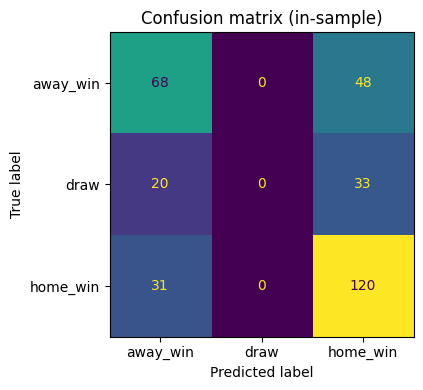

In [ ]:
# Fit the final model on the full training dataset
X_scaled = scaler.fit_transform(X)
lr.fit(X_scaled, y)

# Store class order (used by prediction functions)
CLASS_ORDER = list(lr.classes_)  # e.g. ['away_win', 'draw', 'home_win']
print('Class order:', CLASS_ORDER)

# Confusion matrix on the full training set (in-sample - just for exploration)
y_pred = lr.predict(X_scaled)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=CLASS_ORDER,
    ax=ax,
    colorbar=False
)
ax.set_title('Confusion matrix (in-sample)')
plt.tight_layout()
plt.show()

### Coefficient bar chart - what drives World Cup outcomes?

Chart saved to outputs\lr_coefficients.png


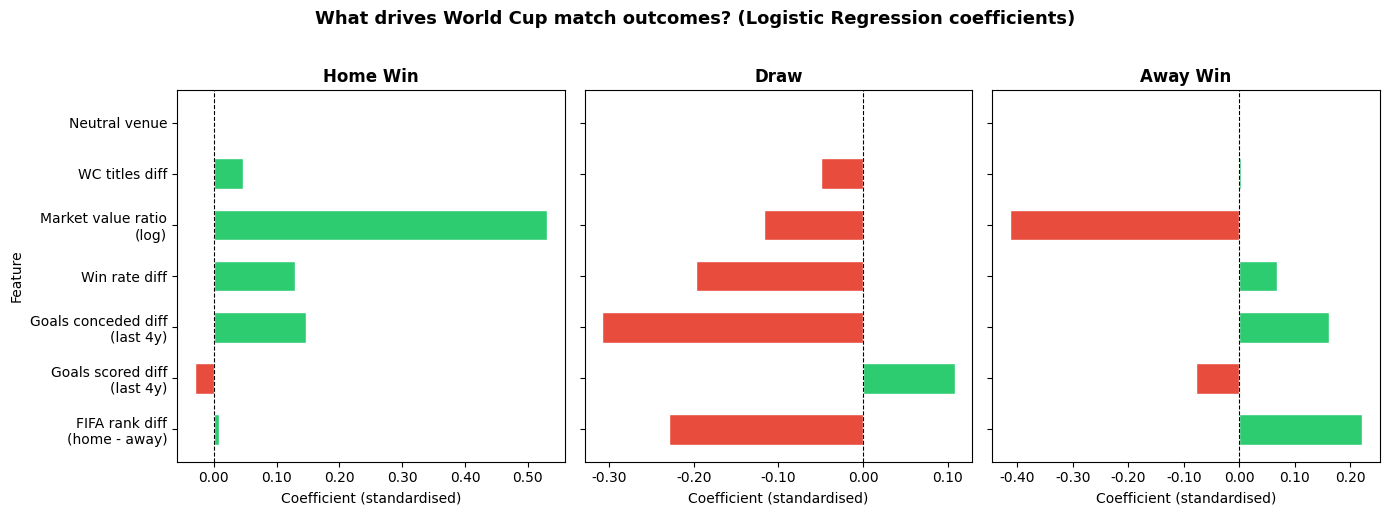

In [ ]:
feature_labels = [
    'FIFA rank diff\n(home - away)',
    'Goals scored diff\n(last 4y)',
    'Goals conceded diff\n(last 4y)',
    'Win rate diff',
    'Market value ratio\n(log)',
    'WC titles diff',
    'Neutral venue',
]

coef_df = pd.DataFrame(
    lr.coef_,
    index=CLASS_ORDER,
    columns=feature_labels
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle(
    'What drives World Cup match outcomes? (Logistic Regression coefficients)',
    fontsize=13, fontweight='bold', y=1.02
)

class_titles = {
    'home_win': 'Home Win',
    'draw':     'Draw',
    'away_win': 'Away Win',
}

for ax, cls in zip(axes, ['home_win', 'draw', 'away_win']):
    if cls not in coef_df.index:
        ax.set_visible(False)
        continue
    vals = coef_df.loc[cls]
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]
    ax.barh(feature_labels, vals, color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(class_titles.get(cls, cls), fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardised)')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[0].set_ylabel('Feature')
plt.tight_layout()
out_path = OUTPUTS / 'lr_coefficients.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Chart saved to {out_path}')
plt.show()

---
## Step 3 - Prediction Functions

These functions are loaded into `predictions.ipynb` when you run `%run lr_model.ipynb`.

| Function | Used for |
|---|---|
| `predict_winner` / `predict_score` | Match outcomes (LR model) |
| `get_lr_proba` | Full win/draw/loss probabilities (new) |
| `get_elo` | Standings display and tiebreakers only |

**How the two models coexist:** LR drives every match prediction. ELO is kept purely because `predictions.ipynb` uses `get_elo()` to populate the standings table and break ties when points, goal difference, and goals scored are equal. The knockout `w_elo` / `l_elo` columns will show LR win probabilities (0-1) rather than ELO ratings — that is expected when running the LR model.

In [ ]:
# ELO helpers (standings display + tiebreakers in predictions.ipynb) 

elo_raw = pd.read_csv(DATA / 'elo_ratings_wc2026.csv')
elo_2026 = (
    elo_raw[elo_raw['snapshot_date'] == '2026-05-27']
    .copy()
    .reset_index(drop=True)
)

ELO_ALIASES: dict[str, str] = {
    'USA':              'United States',
    'IR Iran':          'Iran',
    "Côte d'Ivoire":    'Ivory Coast',
    'Cabo Verde':       'Cape Verde',
    'DR Congo':         'DR Congo',
    'United States':    'United States',
    'Iran':             'Iran',
    'Ivory Coast':      'Ivory Coast',
    'Cape Verde':       'Cape Verde',
    'Czech Republic':   'Czechia',
    'Cura\u00e7ao':     'Cura\u00e7ao',
}

_elo_lookup: dict[str, float] = dict(zip(elo_2026['country'], elo_2026['rating']))

def _canonical_elo(name: str) -> str:
    return ELO_ALIASES.get(name, name)

def get_elo(team_name: str) -> float:
    """Pre-tournament ELO rating. Used by predictions.ipynb for standings only."""
    canon = _canonical_elo(team_name)
    if canon in _elo_lookup:
        return _elo_lookup[canon]
    if team_name in _elo_lookup:
        return _elo_lookup[team_name]
    raise KeyError(f'No Elo rating found for "{team_name}" (canonical: "{canon}")')

def _predict_winner_elo(home: str, away: str) -> tuple[str, str, float, float]:
    """ELO fallback when LR features are unavailable for a team."""
    home_elo = get_elo(home)
    away_elo = get_elo(away)
    if home_elo >= away_elo:
        return home, away, home_elo, away_elo
    return away, home, away_elo, home_elo

print(f'ELO lookup ready ({len(_elo_lookup)} teams)')


# LR feature lookup (test.csv pre-tournament stats) 

TEST_NAME_MAP: dict[str, str] = {
    'USA':              'United States',
    'IR Iran':          'Iran',
    "Cote d'Ivoire":    'Ivory Coast',
    "Côte d'Ivoire":    'Ivory Coast',
    'Cabo Verde':       'Cape Verde',
    'Czechia':          'Czech Republic',
    'Cura\u00e7ao':     'Cura?o',
}

_test_features: dict[str, dict] = {}
for _, row in test_df.iterrows():
    _test_features[row['team']] = row

for teams_name, test_name in TEST_NAME_MAP.items():
    if test_name in _test_features:
        _test_features[teams_name] = _test_features[test_name]

def _resolve(name: str) -> str:
    """Resolve teams.csv name to the key used in test.csv."""
    return TEST_NAME_MAP.get(name, name)


def _build_features(home: str, away: str) -> np.ndarray | None:
    """Compute the difference feature vector for a 2026 match."""
    h = _resolve(home)
    a = _resolve(away)
    hr = _test_features.get(h)
    ar = _test_features.get(a)
    if hr is None:
        print(f'WARNING: "{home}" (resolved: "{h}") not found in test.csv - falling back to ELO')
        return None
    if ar is None:
        print(f'WARNING: "{away}" (resolved: "{a}") not found in test.csv - falling back to ELO')
        return None

    home_gp = (hr['wins_last_4y'] + hr['losses_last_4y'] + hr['draws_last_4y']) or 1
    away_gp = (ar['wins_last_4y'] + ar['losses_last_4y'] + ar['draws_last_4y']) or 1
    home_mv = max(float(hr['squad_total_market_value_eur']), 1e6)
    away_mv = max(float(ar['squad_total_market_value_eur']), 1e6)

    return np.array([
        hr['fifa_rank_pre_tournament']    - ar['fifa_rank_pre_tournament'],
        hr['goals_scored_last_4y']        - ar['goals_scored_last_4y'],
        hr['goals_received_last_4y']      - ar['goals_received_last_4y'],
        (hr['wins_last_4y'] / home_gp)    - (ar['wins_last_4y'] / away_gp),
        np.log(home_mv / away_mv),
        hr['world_cup_titles_before']     - ar['world_cup_titles_before'],
        1,
    ], dtype=float)

print(f'LR test features loaded for {len(_test_features)} name variants')

ELO lookup ready (48 teams)
LR test features loaded for 55 name variants


In [ ]:
# return probabilities of each possible result
def get_lr_proba(home: str, away: str) -> dict[str, float]:
    feat = _build_features(home, away)
    if feat is None:
        return {'home_win': float('nan'), 'draw': float('nan'), 'away_win': float('nan')}
    feat_scaled = scaler.transform(feat.reshape(1, -1))
    proba = lr.predict_proba(feat_scaled)[0]
    return {cls: float(p) for cls, p in zip(CLASS_ORDER, proba)}


def predict_knockout_winner(
    home: str, away: str
) -> tuple[str, str, float, float]:
    """Predict the winner of a knockout match (draw impossible).

    Compares P(home_win) vs P(away_win) only, ignoring draw probability.
    Returns (winner, loser, winner_prob, loser_prob).
    """
    feat = _build_features(home, away)
    if feat is None:
        return _predict_winner_elo(home, away)

    feat_scaled = scaler.transform(feat.reshape(1, -1))
    proba = lr.predict_proba(feat_scaled)[0]
    prob_map = dict(zip(CLASS_ORDER, proba))

    p_home = prob_map.get('home_win', 0.0)
    p_away = prob_map.get('away_win', 0.0)

    if p_home >= p_away:
        return home, away, p_home, p_away
    else:
        return away, home, p_away, p_home


def predict_group_match(
    home: str, away: str
) -> tuple[int, int, str | None]:
    """Predict a group-stage match where draws are possible.

    If P(draw) is the highest of the three probabilities, returns a 1-1
    draw. Otherwise returns the win scoreline. Winner is None for draws.

    Returns (home_goals, away_goals, winner_name_or_None).
    """
    proba = get_lr_proba(home, away)
    p_draw = proba.get('draw', 0.0)
    p_home = proba.get('home_win', 0.0)
    p_away = proba.get('away_win', 0.0)

    if p_draw > p_home and p_draw > p_away:
        return 1, 1, None

    # Win: winner is whoever has higher win probability
    winner, loser, wp, lp = predict_knockout_winner(home, away)
    goals_w = 2 if (wp - lp) > 0.30 else 1
    if winner == home:
        return goals_w, 0, winner
    else:
        return 0, goals_w, winner


def predict_winner_lr(
    home: str, away: str
) -> tuple[str, str, float, float]:
    """Legacy wrapper: predicts a winner (no draws). Used as predict_winner alias."""
    return predict_knockout_winner(home, away)


def predict_score_lr(home: str, away: str) -> tuple[int, int]:
    """Legacy wrapper: returns scoreline without draw support.

    Returns (home_goals, away_goals) - same signature as predict_score().
    """
    hg, ag, _ = predict_group_match(home, away)
    return hg, ag


# Expose under the original names so predictions.ipynb works
# without changes when this notebook is %run instead of model.ipynb
predict_winner = predict_winner_lr
predict_score  = predict_score_lr

print('predict_group_match, predict_knockout_winner, get_lr_proba - ready.')
print('predict_winner and predict_score aliased to LR versions.')

predict_group_match, predict_knockout_winner, get_lr_proba - ready.
predict_winner and predict_score aliased to LR versions.


---
## Step 4 - Integration Check

Run a few sample predictions to confirm the output format is identical to what `predictions.ipynb` expects.

In [ ]:
test_pairs = [
    ('Mexico',     'South Africa'),
    ('South Korea', 'Czechia'),
    ('Canada', 'Bosnia and Herzegovina'),
    ('United States', 'Paraguay')
]

print('-- Group match (draws allowed) --')
print(f'{"Match":<28} {"Result":<8} {"Winner/Draw":<14} {"Proba (hw / d / aw)"}')
print('-' * 75)
for home, away in test_pairs:
    hg, ag, winner = predict_group_match(home, away)
    proba = get_lr_proba(home, away)
    hw = proba.get('home_win', float('nan'))
    d  = proba.get('draw',     float('nan'))
    aw = proba.get('away_win', float('nan'))
    label = winner if winner else 'Draw'
    print(
        f'{home} vs {away:<18} {hg}-{ag}     {label:<14} '
        f'hw={hw:.2f}  d={d:.2f}  aw={aw:.2f}'
    )

print()
print('-- Knockout (no draws) --')
print(f'{"Match":<28} {"Winner":<14} {"Win Prob"}')
print('-' * 55)
for home, away in test_pairs:
    winner, loser, wp, lp = predict_knockout_winner(home, away)
    print(f'{home} vs {away:<18} {winner:<14} {wp:.3f}')
    hw = proba.get('home_win', float('nan'))
    d  = proba.get('draw',     float('nan'))
    aw = proba.get('away_win', float('nan'))
    print(
        f'{home} vs {away:<18} {winner:<14} {hg}-{ag}      '
        f'hw={hw:.2f}  d={d:.2f}  aw={aw:.2f}'
    )

-- Group match (draws allowed) --
Match                        Result   Winner/Draw    Proba (hw / d / aw)
---------------------------------------------------------------------------
Mexico vs South Africa       2-0     Mexico         hw=0.63  d=0.17  aw=0.19
South Korea vs Czechia            1-0     South Korea    hw=0.45  d=0.22  aw=0.32
Canada vs Bosnia and Herzegovina 0-1     Bosnia and Herzegovina hw=0.27  d=0.33  aw=0.40
United States vs Paraguay           1-0     United States  hw=0.57  d=0.13  aw=0.29

-- Knockout (no draws) --
Match                        Winner         Win Prob
-------------------------------------------------------
Mexico vs South Africa       Mexico         0.635
Mexico vs South Africa       Mexico         1-0      hw=0.57  d=0.13  aw=0.29
South Korea vs Czechia            South Korea    0.450
South Korea vs Czechia            South Korea    1-0      hw=0.57  d=0.13  aw=0.29
Canada vs Bosnia and Herzegovina Bosnia and Herzegovina 0.397
Canada vs Bosnia and 